🌟 **Daily Challenge: Data Handling and Analysis in Python**

Use Pandas to explore salaries, normalize salary values, reduce features with PCA, and calculate average and median salaries by experience level.

Data: the supplied `datascience_salaries.csv`. Keep this file beside the notebook and run the cells from top to bottom. Required packages: numpy, pandas, matplotlib and scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from IPython.display import display

salary_df = pd.read_csv("datascience_salaries.csv")

print("Original shape:", salary_df.shape)
display(salary_df.head(5))

Original shape: (1171, 7)


,Unnamed: 0,job_title,job_type,experience_level,location,salary_currency,salary
0,0,Data scientist,Full Time,Senior,New York City,USD,149000
1,2,Data scientist,Full Time,Senior,Boston,USD,120000
2,3,Data scientist,Full Time,Senior,London,USD,68000
3,4,Data scientist,Full Time,Senior,Boston,USD,120000
4,5,Data scientist,Full Time,Senior,New York City,USD,149000


**🌟 Exercise 1: Data Exploration and Cleaning**

In [2]:
# Remove the saved CSV index because it is not a job feature.
salary_df = salary_df.drop(columns=salary_df.filter(regex="^Unnamed:").columns)

salary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_title         1171 non-null   object
 1   job_type          1171 non-null   object
 2   experience_level  1171 non-null   object
 3   location          1171 non-null   object
 4   salary_currency   1171 non-null   object
 5   salary            1171 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 55.0+ KB


None

In [3]:
# Identify missing values and repeated job records.
print("Missing values:")
print(salary_df.isnull().sum())
print("Repeated rows:", salary_df.duplicated().sum())

display(salary_df["experience_level"].value_counts())
display(salary_df["salary_currency"].value_counts())

Missing values:
job_title           0
job_type            0
experience_level    0
location            0
salary_currency     0
salary              0
dtype: int64
Repeated rows: 345


experience_level
Senior       727
Mid          305
Entry        126
Executive     13
Name: count, dtype: int64

salary_currency
USD    1157
EUR       9
GBP       5
Name: count, dtype: int64

None

Repeated job records are kept because matching job details do not establish that they are accidental duplicates. The saved CSV index is not a person or job identifier. Missing or invalid salaries are removed rather than replaced with an average.

In [4]:
# Clean salary values and remove rows missing required analysis fields.
salary_df["salary"] = pd.to_numeric(salary_df["salary"], errors="coerce")
salary_df["salary"] = salary_df["salary"].replace([np.inf, -np.inf], np.nan)

rows_before = len(salary_df)
salary_df = salary_df.dropna(subset=["salary", "salary_currency", "experience_level"]).copy()
salary_df = salary_df[salary_df["salary"] > 0].copy()

print("Rows removed:", rows_before - len(salary_df))
print("Shape after cleaning:", salary_df.shape)
display(salary_df["salary"].describe())

Rows removed: 0
Shape after cleaning: (1171, 6)


count      1171.000000
mean      64836.037575
std       32551.767046
min       30000.000000
25%       45000.000000
50%       63000.000000
75%       68000.000000
max      228000.000000
Name: salary, dtype: float64

None

**🌟 Exercise 2: Min-Max Normalization**

Min-Max normalization uses `(salary - minimum) / (maximum - minimum)`. I create a new column and keep the original salaries. The requested normalization is applied to all salary values, but scaling does not convert currencies or make salaries in different currencies comparable.

In [5]:
# Normalize the salary column between 0 and 1.
min_max_scaler = MinMaxScaler()
salary_df["salary_normalized"] = min_max_scaler.fit_transform(salary_df[["salary"]]).ravel()

display(salary_df[["salary", "salary_currency", "salary_normalized"]].head())

,salary,salary_currency,salary_normalized
0,149000,USD,0.601010
1,120000,USD,0.454545
2,68000,USD,0.191919
3,120000,USD,0.454545
4,149000,USD,0.601010


None

In [6]:
# Verify the minimum and maximum normalized values.
print("Minimum normalized salary:", salary_df["salary_normalized"].min())
print("Maximum normalized salary:", salary_df["salary_normalized"].max())

assert salary_df["salary_normalized"].between(0, 1).all()
assert np.isclose(salary_df["salary_normalized"].min(), 0)
assert np.isclose(salary_df["salary_normalized"].max(), 1)

Minimum normalized salary: 0.0
Maximum normalized salary: 1.0


**🌟 Exercise 3: Dimensionality Reduction with PCA**

This file has one numerical job feature, salary. I encode job title, job type, and location into numerical indicator columns before PCA. I use USD records so salary has a consistent unit. Experience level is reserved for coloring the plot rather than included as a PCA input.

Salary is standardized to prevent its large units from dominating. Indicator columns remain 0 or 1 so rare locations are not given extra weight through standardization. This is an exploratory choice: a different encoding or weighting can change the PCA results.

In [7]:
# Select salaries recorded in USD for a common-currency analysis.
usd_df = salary_df[salary_df["salary_currency"] == "USD"].copy()

print("USD records:", len(usd_df))
print("Other-currency records excluded from PCA:", len(salary_df) - len(usd_df))

USD records: 1157
Other-currency records excluded from PCA: 14


None

In [8]:
# Encode categorical job features as numerical indicator columns.
categorical_columns = ["job_title", "job_type", "location"]
categorical_features = usd_df[categorical_columns].fillna("Unknown")
encoded_features = pd.get_dummies(categorical_features, dtype=int)

# Standardize salary and combine it with the encoded job features.
standard_scaler = StandardScaler()
scaled_salary = standard_scaler.fit_transform(usd_df[["salary"]]).ravel()
pca_features = encoded_features.copy()
pca_features["salary_scaled"] = scaled_salary

print("Shape before PCA:", pca_features.shape)
display(pca_features.head())

Shape before PCA: (1157, 326)


,job_title_Big data,job_title_Data analyst,job_title_Data scientist,job_title_ML Ops,job_title_Machine learning,job_type_Full Time,job_type_Internship,location_Aarhus,location_Aberdeen,location_Abu Dhabi,location_Ahmedabad,location_Amsterdam,location_Angeles,location_Ann Arbor,location_Antwerp,location_Arlington,location_Asia,location_Athens,location_Athina,location_Atlanta,location_Austin,location_Australia,location_Aventura,location_Baar,location_Ballerup,location_Bang Kapi District,location_BangPa-in,location_Bangkok,location_Barcelona,location_Basel,location_Beaverton,location_Belfast,location_Belgrade,location_Belo Horizonte,location_Bengaluru,location_Berchem,location_Berkeley,location_Berlin,location_Bogota,location_Bogotá,...,location_Tel-Aviv,location_Toronto,location_Toulouse,location_Tunis,location_U.S. Remote,location_UK,location_UK/EU or compatible timezone (Remote),location_US / Remote,location_US Remote,location_US east coast,location_USA,location_USA (remote),location_United Kingdom - Remote,location_United States,location_United States (Remote),location_United States - Remote,location_Utrecht,location_Valencia,location_Vancouver,location_Vero Beach,location_Vienna,location_Vietnam - Remote,location_Walnut Creek,location_Warsaw,location_Warszawa,location_Washington,location_Washington DC - will also consider remote …,location_West Jakarta,location_West Palm Beach,location_West Point,location_Westminster,location_Wien,location_Wilmington,location_Work from Home,location_Wrocław,location_Zurich,location_tel aviv,location_České Budějovice,location_İstanbul,salary_scaled
0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.571121
1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.683097
2,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.090779
3,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.683097
4,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.571121


None

In [9]:
# Reduce the encoded features to two principal components.
pca = PCA(n_components=2, svd_solver="full")
principal_components = pca.fit_transform(pca_features)

pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"], index=usd_df.index)

print("Shape after PCA:", pca_df.shape)
display(pca_df.head())

Shape after PCA: (1157, 2)


,PC1,PC2
0,2.614919,0.563318
1,1.718871,0.630473
2,0.105893,0.729117
3,1.718871,0.630473
4,2.614919,0.563318


None

In [10]:
# Measure how much of the prepared feature variance is retained.
explained_variance = pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"])
retained_variance = explained_variance.sum()

print("Explained variance (%):")
print((explained_variance * 100).round(2))
print(f"Total variance retained: {retained_variance:.2%}")
print(f"Variance not retained: {1 - retained_variance:.2%}")

assert pca_df.shape == (len(usd_df), 2)
assert np.isfinite(principal_components).all()

Explained variance (%):
PC1    36.63
PC2    11.72
dtype: float64
Total variance retained: 48.34%
Variance not retained: 51.66%


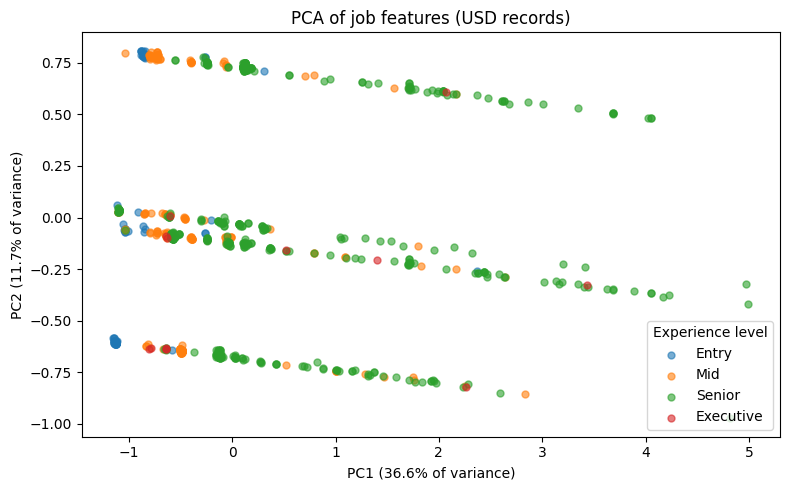

None

In [11]:
# Visualize the reduced data using the experience labels in this file.
experience_order = ["Entry", "Mid", "Senior", "Executive"]
fig, ax = plt.subplots(figsize=(8, 5))

for level in experience_order:
    level_mask = usd_df["experience_level"] == level
    ax.scatter(pca_df.loc[level_mask, "PC1"], pca_df.loc[level_mask, "PC2"],
               label=level, alpha=0.6, s=25)

ax.set_title("PCA of job features (USD records)")
ax.set_xlabel(f"PC1 ({explained_variance['PC1']:.1%} of variance)")
ax.set_ylabel(f"PC2 ({explained_variance['PC2']:.1%} of variance)")
ax.legend(title="Experience level")
plt.tight_layout()
plt.savefig("salary_pca.png", dpi=150)
plt.show()

PCA creates combinations of the encoded features. The plot summarizes two directions of variation; it does not prove that experience groups form separate clusters. The reported retained variance applies to the prepared feature matrix, and the other components contain information omitted from this plot.

**🌟 Exercise 4: Salary Aggregation by Experience Level**

The dataset contains USD, EUR, and GBP salaries and has no converted salary column or exchange-rate date. I calculate mean and median salary by experience level within each currency, then compare experience levels using USD records only. This avoids averaging different monetary units together.

In [12]:
# Calculate salary statistics by experience level within each currency.
currency_summary = salary_df.groupby(["salary_currency", "experience_level"])["salary"].agg(["count", "mean", "median"])

display(currency_summary.round(2))

count      mean   median
salary_currency experience_level                          
EUR             Mid                   2  54000.00  54000.0
                Senior                7  45285.71  36000.0
GBP             Mid                   4  48750.00  45000.0
                Senior                1  57000.00  57000.0
USD             Entry               126  36111.11  30000.0
                Executive            13  76076.92  46000.0
                Mid                 299  51812.71  51000.0
                Senior              719  75403.34  68000.0

None

In [13]:
# Compare the experience groups using USD salaries only.
salary_summary = usd_df.groupby("experience_level")["salary"].agg(["count", "mean", "median"])
salary_summary = salary_summary.reindex(experience_order)

print("Salary summary in USD:")
display(salary_summary.round(2))

Salary summary in USD:


,count,mean,median
experience_level,,,
Entry,126,36111.11,30000.0
Mid,299,51812.71,51000.0
Senior,719,75403.34,68000.0
Executive,13,76076.92,46000.0


None

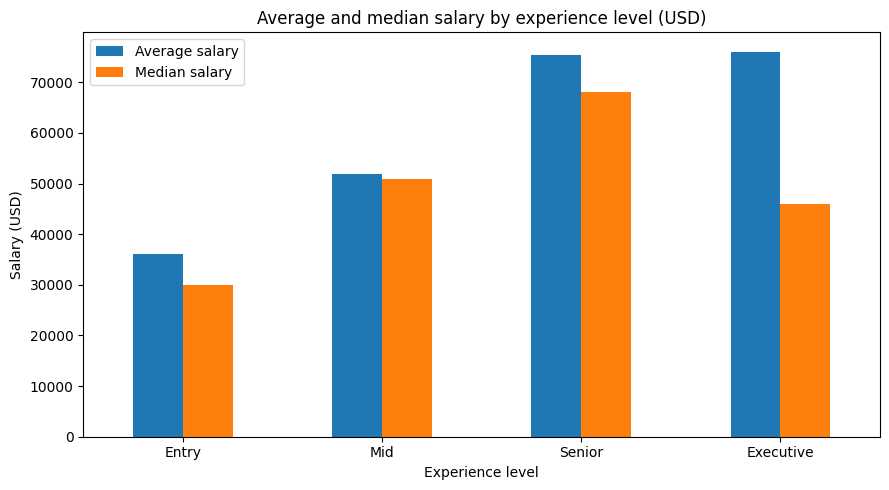

None

In [14]:
# Visualize the average and median salary for each experience level.
ax = salary_summary[["mean", "median"]].plot(kind="bar", figsize=(9, 5))

ax.set_title("Average and median salary by experience level (USD)")
ax.set_xlabel("Experience level")
ax.set_ylabel("Salary (USD)")
ax.legend(["Average salary", "Median salary"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("salary_by_experience.png", dpi=150)
plt.show()

**🌟 Summary of Insights**

In [15]:
# Summarize the calculated results.
highest_mean_level = salary_summary["mean"].idxmax()
highest_median_level = salary_summary["median"].idxmax()
smallest_group = salary_summary["count"].idxmin()

print(f"The analysis includes {len(salary_df)} records, including {len(usd_df)} USD records.")
print("The normalized salary ranges from 0 to 1.")
print(f"PCA reduces {pca_features.shape[1]} encoded features to 2 and retains {retained_variance:.2%} of their variance.")
print(f"{highest_mean_level} has the highest average USD salary: ${salary_summary.loc[highest_mean_level, 'mean']:,.2f}.")
print(f"{highest_median_level} has the highest median USD salary: ${salary_summary.loc[highest_median_level, 'median']:,.2f}.")
print(f"{smallest_group} has the smallest USD group: {salary_summary.loc[smallest_group, 'count']:.0f} records.")
print("Average USD salary rises across all experience levels:", salary_summary["mean"].is_monotonic_increasing)
print("Median USD salary rises across all experience levels:", salary_summary["median"].is_monotonic_increasing)

The analysis includes 1171 records, including 1157 USD records.
The normalized salary ranges from 0 to 1.
PCA reduces 326 encoded features to 2 and retains 48.34% of their variance.
Executive has the highest average USD salary: $76,076.92.
Senior has the highest median USD salary: $68,000.00.
Executive has the smallest USD group: 13 records.
Average USD salary rises across all experience levels: True
Median USD salary rises across all experience levels: False


None

The mean is affected by high salaries, while the median represents the middle record. Compare both measures before deciding which group earns more. The small executive group makes its results less stable.

These are descriptive comparisons for this file. Job title, job type, and location can differ between groups, so experience alone does not explain the salary differences. The file has no work-year column, so it does not support conclusions about salary trends over time. The USD comparison excludes EUR and GBP records; their separate summaries are shown above.